# Phase 4d - Normalized PINN-Feature Hybrid External Validation

**Question.** After capacity normalization rescues Phase 4, do the
PINN-inspired physics descriptors improve external transfer further?

This notebook retrains scale-free LSTMs on Luh/Blank using:

- `SOH = Q / Q0`
- `Re_norm = Re / Re0`
- optional PINN-feature descriptors: `Ea_kJ_mol_mean` and log-Arrhenius stress

Then it evaluates frozen transfer to Kirkaldy using BOL-seeded autoregressive
rollout in normalized space. It also converts SOH predictions back to capacity:

- `Q_pred = SOH_pred * Q0`

**Inputs to attach in Kaggle**
1. Luh/Blank processed output containing `phase2_train.csv`, `phase2_val.csv`,
   and `phase2_test.csv`.
2. Kirkaldy dataset containing `Performance Summary/*.csv`.


In [49]:
import json
import math
import os
import random
import re
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

KAGGLE_INPUT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path(".")
    WORKING = Path(".")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_FAST = bool(int(os.environ.get("PHASE4D_FAST", "0")))
RUN_TAG = "phase4d_normalized_pinn_hybrid_external_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 20
EPOCHS = 45 if RUN_FAST else 140
PATIENCE = 10 if RUN_FAST else 25
BATCH_SIZE = 512
EPS = 1e-9

BASE_FEATS = [
    "k_exp",
    "temperature",
    "c_rate_chg",
    "c_rate_dischg",
    "soc_window",
    "age_type",
]
PINN_FEATS = BASE_FEATS + ["stress", "stress_logEa", "Ea_kJ_mol_mean"]
HIST_TARGETS = ["SOH", "Re_norm"]
TARGETS = ["SOH", "Re_norm"]
VARIANTS = {
    "NormSOH_LSTM_base": BASE_FEATS,
    "NormSOH_PINNfeat_LSTM": PINN_FEATS,
}

print("Run tag:", RUN_TAG)
print("Device:", DEVICE)
print("RUN_FAST:", RUN_FAST)
print("Output:", OUT_DIR)


Run tag: phase4d_normalized_pinn_hybrid_external_20260625_095450
Device: cuda
RUN_FAST: False
Output: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450


## 1. Utility Functions


In [50]:
def print_section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def normalize_name(s):
    s = re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower())
    return re.sub(r"_+", "_", s).strip("_")


def to_num(x):
    return pd.to_numeric(x, errors="coerce")


def find_col(columns, keywords, exclude=None):
    exclude = exclude or []
    for kw in keywords:
        for col in columns:
            if kw in col and not any(ex in col for ex in exclude):
                return col
    return None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 3 or np.var(y_true) <= EPS:
        return np.nan
    return float(r2_score(y_true, y_pred))


def metric_row(model, protocol, target, y_true, y_pred, n_cells=None, split=""):
    return {
        "Model": model,
        "Protocol": protocol,
        "Split": split,
        "Target": target,
        "MAPE": mape(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": safe_r2(y_true, y_pred),
        "n": int(len(y_true)),
        "n_cells": n_cells,
    }


def add_normalized_columns(df):
    out = df.copy()
    needed = ["Q", "Q0", "Re", "Re0"]
    for col in needed:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out["SOH"] = out["Q"] / out["Q0"].replace(0, np.nan)
    out["Re_norm"] = out["Re"] / out["Re0"].replace(0, np.nan)
    out["SOH"] = out["SOH"].replace([np.inf, -np.inf], np.nan)
    out["Re_norm"] = out["Re_norm"].replace([np.inf, -np.inf], np.nan)
    return out


def clean_model_table(df):
    out = df.copy()
    if "cell_key" not in out.columns:
        if "cell_id" in out.columns:
            out["cell_key"] = out["cell_id"].astype(str)
        else:
            out["cell_key"] = "cell_" + out.groupby("Q0").cumcount().astype(str)

    if "Ea_kJ_mol_mean" not in out.columns:
        out["Ea_kJ_mol_mean"] = 56.0
    out["Ea_kJ_mol_mean"] = pd.to_numeric(out["Ea_kJ_mol_mean"], errors="coerce").fillna(56.0)

    temp_k = pd.to_numeric(out.get("temperature", 25.0), errors="coerce").fillna(25.0) + 273.15
    k_safe = np.clip(pd.to_numeric(out.get("k_exp", 0.0), errors="coerce").fillna(0.0), 1e-6, None)
    out["stress"] = (
        pd.to_numeric(out.get("c_rate_chg", 0.3), errors="coerce").fillna(0.3).abs()
        * (pd.to_numeric(out.get("soc_window", 1.0), errors="coerce").fillna(1.0).abs() + EPS)
        * np.exp((temp_k - 298.15) / 50.0)
    )
    out["stress_logEa"] = np.log(k_safe) - out["Ea_kJ_mol_mean"].astype(float) / (8.314e-3 * temp_k)

    all_features = sorted(set(BASE_FEATS + PINN_FEATS + TARGETS + ["Q", "Q0", "Re", "Re0", "k_exp"]))
    for col in all_features:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = add_normalized_columns(out)
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out[out["Q"].notna() & out["Q0"].notna() & out["SOH"].notna()].copy()
    out["Re_norm"] = out.groupby("cell_key")["Re_norm"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re_norm"] = out["Re_norm"].fillna(out["Re_norm"].median()).fillna(1.0)
    fill_features = sorted(set(BASE_FEATS + PINN_FEATS))
    out[fill_features] = out[fill_features].fillna(out[fill_features].median(numeric_only=True)).fillna(0.0)
    return out.sort_values(["cell_key", "k_exp"]).reset_index(drop=True)


## 2. Load Luh/Blank Processed Dataset


In [51]:
def discover_luh_pack_dir():
    roots = [KAGGLE_INPUT, WORKING, Path(".")]
    for root in roots:
        if not root.exists():
            continue
        for p in [root] + [x for x in root.rglob("*") if x.is_dir()]:
            if (p / "phase2_train.csv").exists() and (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
                return p
    raise FileNotFoundError("Attach Luh/Blank processed dataset with phase2_train.csv, phase2_val.csv, phase2_test.csv")


PACK_DIR = discover_luh_pack_dir()
train_df = pd.read_csv(PACK_DIR / "phase2_train.csv")
val_df = pd.read_csv(PACK_DIR / "phase2_val.csv")
test_df = pd.read_csv(PACK_DIR / "phase2_test.csv")

def attach_ea_if_available(df):
    out = df.copy()
    if "Ea_kJ_mol_mean" in out.columns:
        return out
    ea_paths = (
        list(KAGGLE_INPUT.rglob("diag_pinn_param_stability_per_cell.csv"))
        + list(KAGGLE_INPUT.rglob("*pinn*param*.csv"))
        + list(Path(".").rglob("diag_pinn_param_stability_per_cell.csv"))
    )
    ea_df = None
    for p in ea_paths:
        try:
            d = pd.read_csv(p)
            if {"cell_id", "Ea_kJ_mol_mean"}.issubset(d.columns):
                ea_df = d[["cell_id", "Ea_kJ_mol_mean"]].copy()
                break
            if {"cell_id", "Ea_kJ_mol_extracted"}.issubset(d.columns):
                ea_df = d[["cell_id", "Ea_kJ_mol_extracted"]].rename(columns={"Ea_kJ_mol_extracted": "Ea_kJ_mol_mean"})
                break
        except Exception:
            continue
    if ea_df is None or "cell_id" not in out.columns:
        out["Ea_kJ_mol_mean"] = 56.0
        return out
    return out.merge(ea_df.drop_duplicates("cell_id"), on="cell_id", how="left")


train_df = attach_ea_if_available(train_df)
val_df = attach_ea_if_available(val_df)
test_df = attach_ea_if_available(test_df)

train_df = clean_model_table(train_df)
val_df = clean_model_table(val_df)
test_df = clean_model_table(test_df)

print_section("Luh/Blank Normalized Dataset")
print("Pack dir:", PACK_DIR)
print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("Train cells:", train_df["cell_key"].nunique())
print("Q range train:", float(train_df["Q"].min()), "to", float(train_df["Q"].max()))
print("SOH range train:", float(train_df["SOH"].min()), "to", float(train_df["SOH"].max()))
print("Ea range train:", float(train_df["Ea_kJ_mol_mean"].min()), "to", float(train_df["Ea_kJ_mol_mean"].max()))
display(train_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Re", "Re0", "Re_norm", "Ea_kJ_mol_mean", "stress_logEa"]].head())



Luh/Blank Normalized Dataset
Pack dir: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank
Train/Val/Test: (3186, 26) (395, 26) (399, 26)
Train cells: 180
Q range train: 1.516476 to 2.970551
SOH range train: 0.5119144790542142 to 1.0
Ea range train: 51.749260416666665 to 61.47817838541667


,cell_key,k_exp,Q,Q0,SOH,Re,Re0,Re_norm,Ea_kJ_mol_mean,stress_logEa
0,P001_1_S01_C10,0.0,2.967744,2.967744,1.000000,16.318000,16.318,1.000000,53.474408,-37.362466
1,P001_1_S01_C10,0.0,2.962058,2.967744,0.998084,17.316515,16.318,1.061191,53.474408,-37.362466
2,P001_1_S01_C10,0.0,2.951028,2.967744,0.994367,17.316515,16.318,1.061191,53.474408,-37.362466
3,P001_1_S01_C10,0.0,2.936992,2.967744,0.989638,17.316515,16.318,1.061191,53.474408,-37.362466
4,P001_1_S01_C10,0.0,2.921269,2.967744,0.984340,17.316515,16.318,1.061191,53.474408,-37.362466


## 3. Build Kirkaldy Normalized Dataset


In [52]:
def count_expt_dirs(path):
    try:
        return len([p for p in path.iterdir() if p.is_dir() and "expt" in p.name.lower()])
    except Exception:
        return 0


def discover_kirkaldy_root():
    perf_dirs = [p for p in KAGGLE_INPUT.rglob("*") if p.is_dir() and p.name == "Performance Summary"]
    if perf_dirs:
        candidates = [p.parent.parent for p in perf_dirs]
        return max(candidates + [p.parent for p in candidates], key=count_expt_dirs)
    candidates = [
        p for p in KAGGLE_INPUT.rglob("*")
        if p.is_dir() and any(token in p.name.lower() for token in ["kirkald", "kirkal"])
    ]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Attach Kirkaldy dataset containing Performance Summary CSVs")


EXP_SOC_MAP = {
    1: (0.00, 0.30),
    2: (0.70, 0.85),
    3: (0.85, 1.00),
    4: (0.00, 1.00),
    5: (0.00, 1.00),
}


def parse_kirkaldy_filename(path):
    name = Path(path).name
    exp_m = re.search(r"[Ee]xp[t]?\.?\s*(\d+)", name)
    temp_m = re.search(r"(\d+)\s*deg", name, re.I)
    cell_m = re.search(r"[Cc]ell\s+([A-Za-z])", name)
    return {
        "exp": int(exp_m.group(1)) if exp_m else None,
        "temp_c": int(temp_m.group(1)) if temp_m else None,
        "cell_id": str(cell_m.group(1)).upper() if cell_m else None,
    }


def build_kirkaldy_table():
    kirk_root = discover_kirkaldy_root()
    perf_csvs = sorted(kirk_root.rglob("Performance Summary/*.csv"))
    perf_csvs = [
        p for p in perf_csvs
        if not any(x in p.name.lower() for x in ["charge_data", "discharge_data", "voltage", "timeseries"])
    ]
    rows = []
    errors = []
    for path in perf_csvs:
        meta = parse_kirkaldy_filename(path)
        if meta["exp"] is None or meta["cell_id"] is None:
            errors.append({"path": str(path), "reason": "filename_parse_failed"})
            continue
        soc_lo, soc_hi = EXP_SOC_MAP.get(meta["exp"], (0.0, 1.0))
        cell_key = f"exp{meta['exp']}_cell{meta['cell_id']}"

        try:
            d = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
        except Exception:
            d = pd.read_csv(path, encoding="latin1", on_bad_lines="skip")
        d.columns = [normalize_name(c) for c in d.columns]

        c_rpt = find_col(d.columns, ["ageing_sets", "ageing_set", "rpt"])
        c_cycles = find_col(d.columns, ["ageing_cycles", "ageing_cycle", "cycles"])
        c_cap10 = find_col(d.columns, ["c_10", "c10"], exclude=["c_2", "c2"])
        c_cap2 = find_col(d.columns, ["c_2", "c2"])
        c_res = find_col(d.columns, ["0_1s_resist", "0_1s_res", "resistance"])
        c_temp = find_col(d.columns, ["age_set_av_temperature", "temperature", "temp"], exclude=["min", "max"])
        cap_col = c_cap10 or c_cap2
        if c_cycles is None or cap_col is None:
            errors.append({"path": str(path), "reason": "missing_capacity_or_cycle"})
            continue

        for j, row in d.iterrows():
            q_mah = to_num(row.get(cap_col))
            cycles = to_num(row.get(c_cycles))
            if not np.isfinite(q_mah) or not np.isfinite(cycles):
                continue
            rpt = to_num(row.get(c_rpt)) if c_rpt else j
            temp = to_num(row.get(c_temp)) if c_temp else meta["temp_c"]
            re_ohm = to_num(row.get(c_res)) if c_res else np.nan
            rows.append({
                "cell_key": cell_key,
                "exp": meta["exp"],
                "cell_id": meta["cell_id"],
                "rpt_idx": float(rpt) if np.isfinite(rpt) else float(j),
                "ageing_cycles": float(cycles),
                "k_exp": np.nan,
                "temperature": float(temp) if np.isfinite(temp) else float(meta["temp_c"] or 25.0),
                "c_rate_chg": 0.3,
                "c_rate_dischg": 1.0,
                "soc_window": float(soc_hi - soc_lo),
                "age_type": 3.0 if meta["exp"] == 4 else 2.0,
                "Q": float(q_mah) / 1000.0,
                "Re": float(re_ohm) * 1000.0 if np.isfinite(re_ohm) else np.nan,
                "source_path": str(path),
            })

    pd.DataFrame(errors).to_csv(OUT_DIR / "phase4d_kirkaldy_parse_errors.csv", index=False)
    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("No Kirkaldy rows parsed.")
    out = out.sort_values(["cell_key", "rpt_idx", "ageing_cycles"]).drop_duplicates(["cell_key", "rpt_idx"], keep="last")
    out = out[out["Q"].notna() & (out["Q"] > 0.1)].copy()
    out["Re"] = out.groupby("cell_key")["Re"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re"] = out["Re"].fillna(out["Re"].median())
    out["k_exp_raw"] = out.groupby("cell_key").cumcount()
    out["k_exp"] = out.groupby("cell_key")["k_exp_raw"].transform(lambda s: s / max(float(s.max()), 1.0))
    out["Q0"] = out.groupby("cell_key")["Q"].transform("first")
    out["Re0"] = out.groupby("cell_key")["Re"].transform("first")
    temp_k = out["temperature"] + 273.15
    out["stress"] = out["c_rate_chg"].abs() * (out["soc_window"].abs() + EPS) * np.exp((temp_k - 298.15) / 50.0)
    out = clean_model_table(out)
    return kirk_root, out


KIRK_ROOT, kirk_df = build_kirkaldy_table()
kirk_df.to_csv(OUT_DIR / "phase4d_kirkaldy_normalized_features.csv", index=False)

print_section("Kirkaldy Normalized Dataset")
print("Kirk root:", KIRK_ROOT)
print("Rows/cells:", kirk_df.shape, kirk_df["cell_key"].nunique())
print("Q range:", float(kirk_df["Q"].min()), "to", float(kirk_df["Q"].max()))
print("SOH range:", float(kirk_df["SOH"].min()), "to", float(kirk_df["SOH"].max()))
display(kirk_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Re", "Re0", "Re_norm", "Ea_kJ_mol_mean", "stress_logEa"]].head())



Kirkaldy Normalized Dataset
Kirk root: /kaggle/input/datasets/simhaatt/kirkaldt-battery-dataset
Rows/cells: (128, 22) 8
Q range: 3.5242181439999998 to 4.884448614
SOH range: 0.7223409558959907 to 1.0


,cell_key,k_exp,Q,Q0,SOH,Re,Re0,Re_norm,Ea_kJ_mol_mean,stress_logEa
0,exp5_cellA,0.000000,4.878885,4.878885,1.000000,25.898870,25.89887,1.000000,56.0,-37.603703
1,exp5_cellA,0.066667,4.602523,4.878885,0.943355,26.668332,25.89887,1.029710,56.0,-25.926268
2,exp5_cellA,0.133333,4.444773,4.878885,0.911022,27.437794,25.89887,1.059421,56.0,-25.239674
3,exp5_cellA,0.200000,4.312811,4.878885,0.883975,92.781966,25.89887,3.582472,56.0,-24.833820
4,exp5_cellA,0.266667,4.216657,4.878885,0.864267,158.126138,25.89887,6.105523,56.0,-24.548756


## 4. Sequence Builder


In [53]:
def seq_features(feature_cols):
    return feature_cols + HIST_TARGETS


def fit_scalers(train, feature_cols):
    cols = seq_features(feature_cols)
    x = train[cols].to_numpy(dtype=float)
    y = train[TARGETS].to_numpy(dtype=float)
    sc_x = StandardScaler().fit(x)
    sc_y = StandardScaler().fit(y)
    return sc_x, sc_y


def build_sequences(df, sc_x, sc_y, feature_cols, seq_len=SEQ_LEN, left_pad=False):
    cols = seq_features(feature_cols)
    xs, ys, meta = [], [], []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True)
        arr_x = g[cols].to_numpy(dtype=float)
        arr_y = g[TARGETS].to_numpy(dtype=float)
        for i in range(1 if left_pad else seq_len, len(g)):
            start = max(0, i - seq_len)
            win = arr_x[start:i].copy()
            if left_pad and len(win) < seq_len:
                pad = np.repeat(win[:1], seq_len - len(win), axis=0)
                win = np.vstack([pad, win])
            if len(win) != seq_len:
                continue
            xs.append(sc_x.transform(win).reshape(seq_len, len(cols)))
            ys.append(sc_y.transform(arr_y[i:i + 1])[0])
            meta.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "Q_true": float(g.loc[i, "Q"]),
                "Q0": float(g.loc[i, "Q0"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
            })
    if not xs:
        return (
            np.empty((0, seq_len, len(cols)), np.float32),
            np.empty((0, len(TARGETS)), np.float32),
            pd.DataFrame(meta),
        )
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32), pd.DataFrame(meta)


def inverse_y(sc_y, y_scaled):
    return sc_y.inverse_transform(np.asarray(y_scaled, dtype=float))


## 5. Train Normalized Base and PINN-Feature Hybrid LSTMs


In [54]:
class LSTMSOH(nn.Module):
    def __init__(self, input_dim, hidden=96, layers=2, output_dim=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, output_dim),
        )

    def forward(self, x):
        y, _ = self.lstm(x)
        return self.head(y[:, -1, :])


def train_variant(variant_name, feature_cols):
    print_section(f"Training {variant_name}")
    train_model_df = pd.concat([train_df, val_df], ignore_index=True)
    sc_x, sc_y = fit_scalers(train_model_df, feature_cols)
    Xtr, ytr, _ = build_sequences(train_model_df, sc_x, sc_y, feature_cols, SEQ_LEN, left_pad=False)
    Xte, yte, meta_te = build_sequences(test_df, sc_x, sc_y, feature_cols, SEQ_LEN, left_pad=False)

    if len(Xtr) == 0 or len(Xte) == 0:
        raise RuntimeError("Not enough Luh/Blank sequence rows. Check cell lengths or lower SEQ_LEN.")

    train_ds = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    model = LSTMSOH(input_dim=len(seq_features(feature_cols))).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    best_state = None
    best_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total = 0.0
        n = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item()) * len(xb)
            n += len(xb)
        train_loss = total / max(n, 1)

        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(Xte, dtype=torch.float32).to(DEVICE)).cpu().numpy()
        y_true = inverse_y(sc_y, yte)
        y_pred = inverse_y(sc_y, val_pred)
        soh_mape = mape(y_true[:, 0], y_pred[:, 0])
        history.append({"variant": variant_name, "epoch": epoch, "train_loss": train_loss, "test_teacher_SOH_MAPE": soh_mape})

        if soh_mape < best_loss:
            best_loss = soh_mape
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"{variant_name} epoch {epoch:03d} train_loss={train_loss:.5f} test_teacher_SOH_MAPE={soh_mape:.3f}")
        if wait >= PATIENCE:
            print(f"{variant_name} early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return {
        "variant": variant_name,
        "feature_cols": feature_cols,
        "model": model,
        "sc_x": sc_x,
        "sc_y": sc_y,
        "Xte": Xte,
        "yte": yte,
        "meta_te": meta_te,
        "history": pd.DataFrame(history),
        "best_teacher_soh_mape": best_loss,
    }


trained = {}
all_history = []
for variant_name, feature_cols in VARIANTS.items():
    trained[variant_name] = train_variant(variant_name, feature_cols)
    all_history.append(trained[variant_name]["history"])

history_df = pd.concat(all_history, ignore_index=True)
history_df.to_csv(OUT_DIR / "phase4d_normalized_hybrid_training_history.csv", index=False)

print_section("Training Complete")
display(pd.DataFrame([
    {"variant": k, "features": ",".join(v["feature_cols"]), "best_teacher_SOH_MAPE": v["best_teacher_soh_mape"]}
    for k, v in trained.items()
]))



Training NormSOH_LSTM_base
NormSOH_LSTM_base epoch 001 train_loss=0.31060 test_teacher_SOH_MAPE=11.459
NormSOH_LSTM_base epoch 010 train_loss=0.14256 test_teacher_SOH_MAPE=5.083
NormSOH_LSTM_base epoch 020 train_loss=0.07134 test_teacher_SOH_MAPE=2.866
NormSOH_LSTM_base epoch 030 train_loss=0.03498 test_teacher_SOH_MAPE=2.063
NormSOH_LSTM_base epoch 040 train_loss=0.02675 test_teacher_SOH_MAPE=2.085
NormSOH_LSTM_base epoch 050 train_loss=0.02213 test_teacher_SOH_MAPE=1.580
NormSOH_LSTM_base epoch 060 train_loss=0.01769 test_teacher_SOH_MAPE=1.441
NormSOH_LSTM_base epoch 070 train_loss=0.01343 test_teacher_SOH_MAPE=1.364
NormSOH_LSTM_base epoch 080 train_loss=0.01062 test_teacher_SOH_MAPE=1.221
NormSOH_LSTM_base epoch 090 train_loss=0.00888 test_teacher_SOH_MAPE=1.039
NormSOH_LSTM_base epoch 100 train_loss=0.00938 test_teacher_SOH_MAPE=0.988
NormSOH_LSTM_base epoch 110 train_loss=0.00836 test_teacher_SOH_MAPE=1.103
NormSOH_LSTM_base early stop at epoch 117

Training NormSOH_PINNfeat_LS

,variant,features,best_teacher_SOH_MAPE
0,NormSOH_LSTM_base,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",0.819535
1,NormSOH_PINNfeat_LSTM,"k_exp,temperature,c_rate_chg,c_rate_dischg,soc...",1.021174


## 6. Luh/Blank Test Evaluation


In [55]:
def teacher_predict(model, X, sc_y):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return inverse_y(sc_y, pred_scaled)


def rollout_predict(df, model, sc_x, sc_y, feature_cols, seq_len=SEQ_LEN, left_pad=True):
    cols = seq_features(feature_cols)
    model.eval()
    pred_rows = []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True).copy()
        if len(g) < 2:
            continue
        buf = g[cols].to_numpy(dtype=float).copy()
        soh_idx = cols.index("SOH")
        re_idx = cols.index("Re_norm")

        for i in range(1 if left_pad else seq_len, len(g)):
            start = max(0, i - seq_len)
            win = buf[start:i].copy()
            if left_pad and len(win) < seq_len:
                pad = np.repeat(win[:1], seq_len - len(win), axis=0)
                win = np.vstack([pad, win])
            if len(win) != seq_len:
                continue
            x = sc_x.transform(win).reshape(1, seq_len, len(cols))
            with torch.no_grad():
                yp_scaled = model(torch.tensor(x, dtype=torch.float32).to(DEVICE)).cpu().numpy()
            yp = inverse_y(sc_y, yp_scaled)[0]
            soh_pred = float(np.clip(yp[0], 0.0, 1.2))
            re_pred = float(max(yp[1], 0.0))
            q0 = float(g.loc[i, "Q0"])
            q_pred = soh_pred * q0
            pred_rows.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "SOH_pred": soh_pred,
                "Q_true": float(g.loc[i, "Q"]),
                "Q_pred": q_pred,
                "Q0": q0,
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
                "Re_norm_pred": re_pred,
            })
            buf[i, soh_idx] = soh_pred
            buf[i, re_idx] = re_pred
    return pd.DataFrame(pred_rows)


metrics = []

for variant_name, bundle in trained.items():
    feature_cols = bundle["feature_cols"]
    model = bundle["model"]
    sc_x = bundle["sc_x"]
    sc_y = bundle["sc_y"]
    Xte = bundle["Xte"]
    meta_te = bundle["meta_te"]

    teacher_pred = teacher_predict(model, Xte, sc_y)
    teacher_rows = meta_te.copy()
    teacher_rows["SOH_pred"] = teacher_pred[:, 0]
    teacher_rows["Re_norm_pred"] = teacher_pred[:, 1]
    teacher_rows["Q_pred"] = teacher_rows["SOH_pred"] * teacher_rows["Q0"]
    teacher_rows.to_csv(OUT_DIR / f"phase4d_{variant_name}_luh_test_teacher_predictions.csv", index=False)

    luh_rollout = rollout_predict(test_df, model, sc_x, sc_y, feature_cols, SEQ_LEN, left_pad=False)
    luh_rollout.to_csv(OUT_DIR / f"phase4d_{variant_name}_luh_test_rollout_predictions.csv", index=False)

    metrics.append(metric_row(variant_name, "teacher_forced", "SOH", teacher_rows["SOH_true"], teacher_rows["SOH_pred"], test_df["cell_key"].nunique(), "Luh_test"))
    metrics.append(metric_row(variant_name, "teacher_forced_restored", "Q", teacher_rows["Q_true"], teacher_rows["Q_pred"], test_df["cell_key"].nunique(), "Luh_test"))
    metrics.append(metric_row(variant_name, "autoregressive_rollout", "SOH", luh_rollout["SOH_true"], luh_rollout["SOH_pred"], luh_rollout["cell_key"].nunique(), "Luh_test"))
    metrics.append(metric_row(variant_name, "autoregressive_rollout_restored", "Q", luh_rollout["Q_true"], luh_rollout["Q_pred"], luh_rollout["cell_key"].nunique(), "Luh_test"))

print_section("Luh/Blank Test Metrics")
display(pd.DataFrame(metrics))



Luh/Blank Test Metrics


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
0,NormSOH_LSTM_base,teacher_forced,Luh_test,SOH,0.819535,0.006099,0.008527,0.991302,76,21
1,NormSOH_LSTM_base,teacher_forced_restored,Luh_test,Q,0.819535,0.018003,0.025184,0.991450,76,21
2,NormSOH_LSTM_base,autoregressive_rollout,Luh_test,SOH,1.151167,0.008601,0.012434,0.981505,76,10
3,NormSOH_LSTM_base,autoregressive_rollout_restored,Luh_test,Q,1.151167,0.025390,0.036723,0.981820,76,10
4,NormSOH_PINNfeat_LSTM,teacher_forced,Luh_test,SOH,1.021174,0.007478,0.012363,0.981716,76,21
5,NormSOH_PINNfeat_LSTM,teacher_forced_restored,Luh_test,Q,1.021174,0.022066,0.036467,0.982072,76,21
6,NormSOH_PINNfeat_LSTM,autoregressive_rollout,Luh_test,SOH,1.255031,0.009311,0.014931,0.973331,76,10
7,NormSOH_PINNfeat_LSTM,autoregressive_rollout_restored,Luh_test,Q,1.255031,0.027468,0.044027,0.973869,76,10


## 7. Kirkaldy External Rollout in Normalized Space


In [56]:
kirk_rollout_by_variant = {}
for variant_name, bundle in trained.items():
    kirk_rollout = rollout_predict(
        kirk_df,
        bundle["model"],
        bundle["sc_x"],
        bundle["sc_y"],
        bundle["feature_cols"],
        SEQ_LEN,
        left_pad=True,
    )
    kirk_rollout_by_variant[variant_name] = kirk_rollout
    kirk_rollout.to_csv(OUT_DIR / f"phase4d_{variant_name}_kirkaldy_normalized_rollout_predictions.csv", index=False)

    metrics.append(metric_row(variant_name, "BOL_seeded_rollout", "SOH", kirk_rollout["SOH_true"], kirk_rollout["SOH_pred"], kirk_rollout["cell_key"].nunique(), "Kirkaldy_external"))
    metrics.append(metric_row(variant_name, "BOL_seeded_rollout_restored", "Q", kirk_rollout["Q_true"], kirk_rollout["Q_pred"], kirk_rollout["cell_key"].nunique(), "Kirkaldy_external"))

# A strong sanity baseline: hold capacity at BOL, i.e. SOH_pred = 1.
kirk_naive = next(iter(kirk_rollout_by_variant.values())).copy()
kirk_naive["SOH_pred"] = 1.0
kirk_naive["Q_pred"] = kirk_naive["Q0"]
metrics.append(metric_row("BOL_persistence", "no_degradation_baseline", "SOH", kirk_naive["SOH_true"], kirk_naive["SOH_pred"], kirk_naive["cell_key"].nunique(), "Kirkaldy_external"))
metrics.append(metric_row("BOL_persistence", "no_degradation_baseline_restored", "Q", kirk_naive["Q_true"], kirk_naive["Q_pred"], kirk_naive["cell_key"].nunique(), "Kirkaldy_external"))

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUT_DIR / "phase4d_normalized_hybrid_external_metrics_summary.csv", index=False)

print_section("Kirkaldy External Metrics")
display(metrics_df[metrics_df["Split"].eq("Kirkaldy_external")].sort_values(["Target", "MAPE"]))



Kirkaldy External Metrics


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
11,NormSOH_PINNfeat_LSTM,BOL_seeded_rollout_restored,Kirkaldy_external,Q,5.206538,0.215096,0.263145,-0.020178,120,8
9,NormSOH_LSTM_base,BOL_seeded_rollout_restored,Kirkaldy_external,Q,6.082495,0.240960,0.291148,-0.248865,120,8
13,BOL_persistence,no_degradation_baseline_restored,Kirkaldy_external,Q,18.443991,0.740459,0.785804,-8.097340,120,8
10,NormSOH_PINNfeat_LSTM,BOL_seeded_rollout,Kirkaldy_external,SOH,5.206538,0.044245,0.054122,-0.004035,120,8
8,NormSOH_LSTM_base,BOL_seeded_rollout,Kirkaldy_external,SOH,6.082495,0.049526,0.059795,-0.225542,120,8
12,BOL_persistence,no_degradation_baseline,Kirkaldy_external,SOH,18.443991,0.152301,0.161595,-7.950749,120,8


## 8. Pointwise Normalized PINN-Feature ExtraTrees Check

This is not the main model. It is a quick sanity check: if a simple normalized
pointwise model transfers better than raw-Q Phase 4, the normalization hypothesis
is plausible.


In [57]:
point_feats = PINN_FEATS
etr = ExtraTreesRegressor(
    n_estimators=400 if not RUN_FAST else 120,
    random_state=SEED,
    min_samples_leaf=2,
    n_jobs=-1,
)
etr_train = pd.concat([train_df, val_df], ignore_index=True).dropna(subset=point_feats + ["SOH"])
etr.fit(etr_train[point_feats], etr_train["SOH"])

etr_pred = np.clip(etr.predict(kirk_df[point_feats]), 0.0, 1.2)
etr_rows = kirk_df[["cell_key", "k_exp", "Q", "Q0", "SOH"]].copy()
etr_rows["SOH_pred"] = etr_pred
etr_rows["Q_pred"] = etr_rows["SOH_pred"] * etr_rows["Q0"]
etr_rows.to_csv(OUT_DIR / "phase4d_kirkaldy_extratrees_pinnfeat_normalized_predictions.csv", index=False)

etr_metrics = pd.DataFrame([
    metric_row("NormSOH_PINNfeat_ExtraTrees", "pointwise_external", "SOH", etr_rows["SOH"], etr_rows["SOH_pred"], etr_rows["cell_key"].nunique(), "Kirkaldy_external"),
    metric_row("NormSOH_PINNfeat_ExtraTrees", "pointwise_external_restored", "Q", etr_rows["Q"], etr_rows["Q_pred"], etr_rows["cell_key"].nunique(), "Kirkaldy_external"),
])
metrics_df = pd.concat([metrics_df, etr_metrics], ignore_index=True)
metrics_df.to_csv(OUT_DIR / "phase4d_normalized_hybrid_external_metrics_summary.csv", index=False)

display(etr_metrics)


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells
0,NormSOH_PINNfeat_ExtraTrees,pointwise_external,Kirkaldy_external,SOH,12.113089,0.099254,0.113724,-2.158923,128,8
1,NormSOH_PINNfeat_ExtraTrees,pointwise_external_restored,Kirkaldy_external,Q,12.113089,0.482623,0.553145,-2.194747,128,8


## 9. Paper Tables and Figures



Paper Table


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,Rank_in_target
0,NormSOH_PINNfeat_LSTM,BOL_seeded_rollout_restored,Kirkaldy_external,Q,5.206538,0.215096,0.263145,-0.020178,120,8,1.0
1,NormSOH_LSTM_base,BOL_seeded_rollout_restored,Kirkaldy_external,Q,6.082495,0.240960,0.291148,-0.248865,120,8,2.0
2,NormSOH_PINNfeat_ExtraTrees,pointwise_external_restored,Kirkaldy_external,Q,12.113089,0.482623,0.553145,-2.194747,128,8,3.0
3,BOL_persistence,no_degradation_baseline_restored,Kirkaldy_external,Q,18.443991,0.740459,0.785804,-8.097340,120,8,4.0
4,NormSOH_PINNfeat_LSTM,BOL_seeded_rollout,Kirkaldy_external,SOH,5.206538,0.044245,0.054122,-0.004035,120,8,1.0
5,NormSOH_LSTM_base,BOL_seeded_rollout,Kirkaldy_external,SOH,6.082495,0.049526,0.059795,-0.225542,120,8,2.0
6,NormSOH_PINNfeat_ExtraTrees,pointwise_external,Kirkaldy_external,SOH,12.113089,0.099254,0.113724,-2.158923,128,8,3.0
7,BOL_persistence,no_degradation_baseline,Kirkaldy_external,SOH,18.443991,0.152301,0.161595,-7.950749,120,8,4.0


Saved: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450/figure_phase4d_restored_q_mape.png


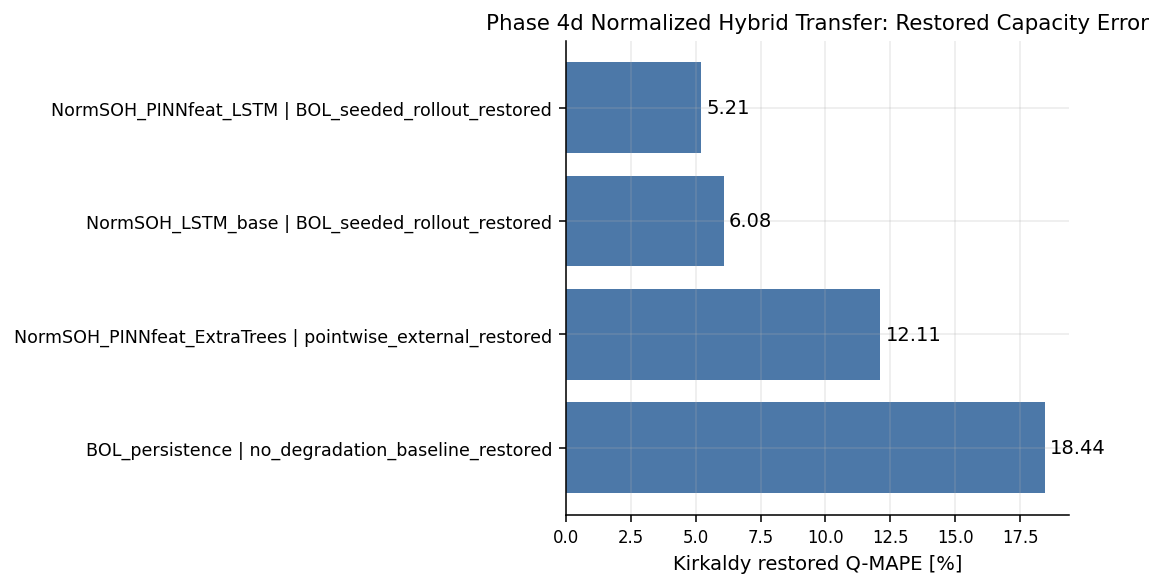

Saved: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450/figure_phase4d_soh_mape.png


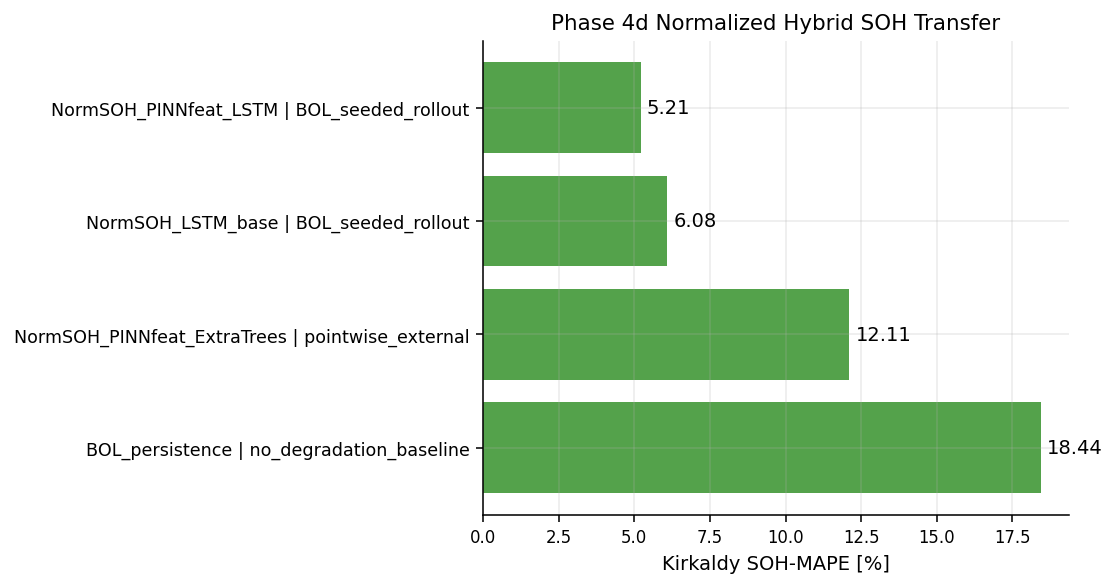

Saved: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450/figure_phase4d_kirkaldy_best_soh_rollout_trajectories.png


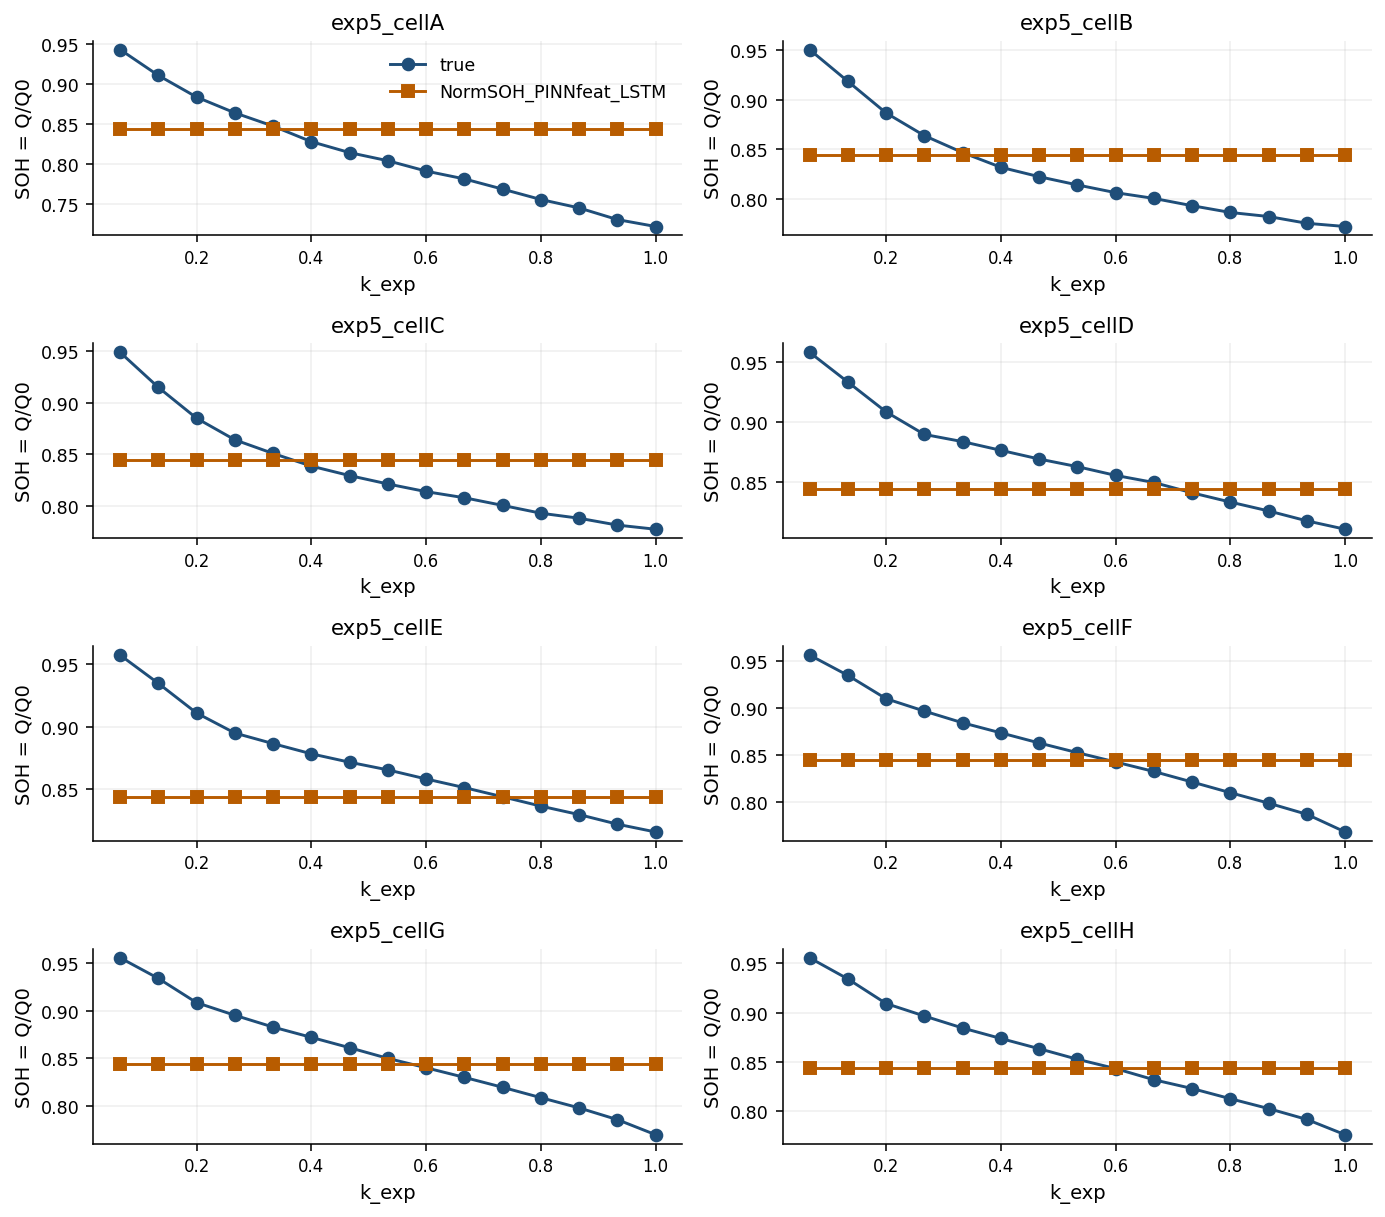

In [58]:
paper_rows = metrics_df[
    metrics_df["Split"].eq("Kirkaldy_external")
    & metrics_df["Target"].isin(["SOH", "Q"])
].copy()
paper_rows["Rank_in_target"] = paper_rows.groupby("Target")["MAPE"].rank(method="min")
paper_rows = paper_rows.sort_values(["Target", "MAPE"]).reset_index(drop=True)
paper_rows.to_csv(OUT_DIR / "phase4d_paper_normalized_hybrid_external_table.csv", index=False)

claims = pd.DataFrame([
    {
        "Claim": "The normalized hybrid tests whether PINN-derived descriptors add value after removing capacity-scale mismatch.",
        "Evidence": "Both LSTM variants predict SOH=Q/Q0 and restore Q after prediction; the hybrid additionally uses Ea_kJ_mol_mean and log-Arrhenius stress.",
        "Paper_Use": "Use this table to decide whether the paper should emphasize normalized LSTM alone or normalized PINN-feature LSTM.",
    },
    {
        "Claim": "Restored-Q MAPE remains the deployable reporting metric.",
        "Evidence": "Q_pred is reconstructed as SOH_pred*Q0 for each Kirkaldy cell.",
        "Paper_Use": "Report both SOH-MAPE and restored Q-MAPE; do not compare normalized SOH-MAPE directly to raw-Q Phase 1 MAPE without explaining the target change.",
    },
    {
        "Claim": "A BOL persistence baseline is necessary.",
        "Evidence": "Kirkaldy cells may degrade slowly across the sampled RPT range, so SOH=1 can be deceptively competitive.",
        "Paper_Use": "A normalized model is useful only if it beats the no-degradation baseline on external SOH/Q metrics.",
    },
])
claims.to_csv(OUT_DIR / "phase4d_normalized_hybrid_claims.csv", index=False)

print_section("Paper Table")
display(paper_rows)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)


fig, ax = plt.subplots(figsize=(8.0, 4.3))
plot = paper_rows[paper_rows["Target"].eq("Q")].sort_values("MAPE")
ax.barh(plot["Model"] + " | " + plot["Protocol"], plot["MAPE"], color="#4C78A8")
ax.invert_yaxis()
ax.set_xlabel("Kirkaldy restored Q-MAPE [%]")
ax.set_title("Phase 4d Normalized Hybrid Transfer: Restored Capacity Error")
for i, v in enumerate(plot["MAPE"]):
    ax.text(v + 0.2, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4d_restored_q_mape.png")
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.3))
plot = paper_rows[paper_rows["Target"].eq("SOH")].sort_values("MAPE")
ax.barh(plot["Model"] + " | " + plot["Protocol"], plot["MAPE"], color="#54A24B")
ax.invert_yaxis()
ax.set_xlabel("Kirkaldy SOH-MAPE [%]")
ax.set_title("Phase 4d Normalized Hybrid SOH Transfer")
for i, v in enumerate(plot["MAPE"]):
    ax.text(v + 0.2, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4d_soh_mape.png")
plt.show()

best_q = paper_rows[paper_rows["Target"].eq("Q")].sort_values("MAPE").iloc[0]
best_model_name = best_q["Model"]
kirk_rollout = kirk_rollout_by_variant.get(best_model_name, next(iter(kirk_rollout_by_variant.values())))
cells = list(kirk_rollout["cell_key"].drop_duplicates())[:8]
fig, axes = plt.subplots(math.ceil(len(cells) / 2), 2, figsize=(10, max(4, 2.2 * math.ceil(len(cells) / 2))), squeeze=False)
for ax, cell in zip(axes.ravel(), cells):
    g = kirk_rollout[kirk_rollout["cell_key"].eq(cell)].sort_values("k_exp")
    ax.plot(g["k_exp"], g["SOH_true"], marker="o", label="true", color="#1F4E79")
    ax.plot(g["k_exp"], g["SOH_pred"], marker="s", label=best_model_name, color="#B85C00")
    ax.set_title(cell)
    ax.set_xlabel("k_exp")
    ax.set_ylabel("SOH = Q/Q0")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(cells):]:
    ax.axis("off")
axes.ravel()[0].legend(frameon=False)
savefig("figure_phase4d_kirkaldy_best_soh_rollout_trajectories.png")
plt.show()


## 10. Export


In [59]:
manifest = {
    "run_tag": RUN_TAG,
    "pack_dir": str(PACK_DIR),
    "kirk_root": str(KIRK_ROOT),
    "seq_len": SEQ_LEN,
    "variants": VARIANTS,
    "base_features": BASE_FEATS,
    "pinn_features": PINN_FEATS,
    "targets": TARGETS,
    "run_fast": RUN_FAST,
    "epochs_requested": EPOCHS,
    "epochs_run_max": int(history_df["epoch"].max()),
    "outputs": sorted([p.name for p in OUT_DIR.iterdir()]),
}
(OUT_DIR / "phase4d_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print_section("Done")
print("Output directory:", OUT_DIR)
print("Zip:", zip_path)
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)



Done
Output directory: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450
Zip: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450.zip
Files:
 - figure_phase4d_kirkaldy_best_soh_rollout_trajectories.png
 - figure_phase4d_restored_q_mape.png
 - figure_phase4d_soh_mape.png
 - phase4d_NormSOH_LSTM_base_kirkaldy_normalized_rollout_predictions.csv
 - phase4d_NormSOH_LSTM_base_luh_test_rollout_predictions.csv
 - phase4d_NormSOH_LSTM_base_luh_test_teacher_predictions.csv
 - phase4d_NormSOH_PINNfeat_LSTM_kirkaldy_normalized_rollout_predictions.csv
 - phase4d_NormSOH_PINNfeat_LSTM_luh_test_rollout_predictions.csv
 - phase4d_NormSOH_PINNfeat_LSTM_luh_test_teacher_predictions.csv
 - phase4d_kirkaldy_extratrees_pinnfeat_normalized_predictions.csv
 - phase4d_kirkaldy_normalized_features.csv
 - phase4d_kirkaldy_parse_errors.csv
 - phase4d_manifest.json
 - phase4d_normalized_hybrid_claims.csv
 - phase4d_normalized_hybrid_external_metrics_summary.csv
 - phase4